# **PRAKTIKUM PERTEMUAN 13 DATA SCIENCE**

Nama : Ninis Indah Trisia

NIM : 250401020094

Kelas : IF405

### Langkah 1: Generate & Eksplorasi Dataset Non-Linear

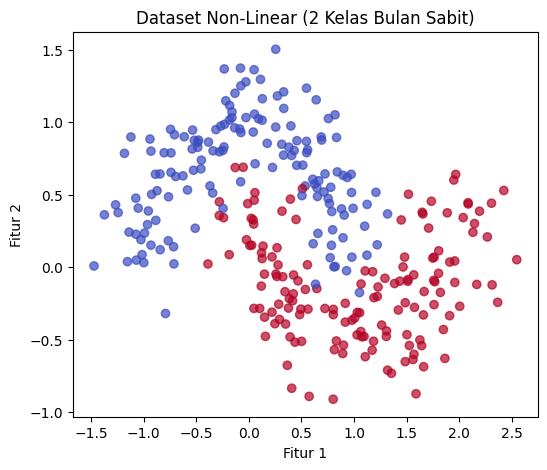

In [1]:
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

# Membuat dataset non-linear
X, y = make_moons(
    n_samples=300,
    noise=0.2,
    random_state=42
)

# Visualisasi dataset
plt.figure(figsize=(6,5))
plt.scatter(
    X[:,0],
    X[:,1],
    c=y,
    cmap="coolwarm",
    alpha=0.7
)

plt.title("Dataset Non-Linear (2 Kelas Bulan Sabit)")
plt.xlabel("Fitur 1")
plt.ylabel("Fitur 2")
plt.show()

Pada langkah ini dibuat dataset menggunakan make_moons() yang menghasilkan dua kelompok data berbentuk bulan sabit. Setelah itu data ditampilkan dalam bentuk grafik agar terlihat pola penyebarannya. Dari grafik terlihat bahwa kedua kelas saling bertautan, sehingga tidak bisa dipisahkan hanya dengan satu garis lurus.

### Langkah 2: Membangun & Melatih Neural Network

In [2]:
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Membagi data menjadi data latih dan data uji
X_tr, X_te, y_tr, y_te = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Membangun arsitektur neural network
model = Sequential([
    Dense(16, activation="relu", input_shape=(2,)),
    Dense(8, activation="relu"),
    Dense(1, activation="sigmoid")
])

# Compile model
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Melihat ringkasan model
model.summary()

# Melatih model
history = model.fit(
    X_tr,
    y_tr,
    epochs=30,
    validation_split=0.2,
    verbose=0
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

Data dibagi menjadi data latih dan data uji. Setelah itu dibuat model Neural Network dengan dua hidden layer menggunakan aktivasi ReLU dan satu output layer menggunakan Sigmoid. Model kemudian dilatih selama 30 epoch agar dapat mempelajari pola pada data.

### Langkah 3: Evaluasi Model & Visualisasi Kurva Belajar

Akurasi pada data uji: 0.883


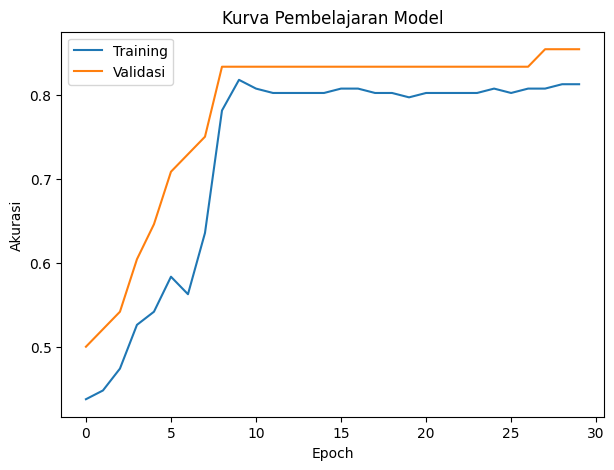

In [3]:
# Evaluasi model
loss, acc = model.evaluate(
    X_te,
    y_te,
    verbose=0
)

print(f"Akurasi pada data uji: {acc:.3f}")

# Plot akurasi
plt.figure(figsize=(7,5))

plt.plot(
    history.history["accuracy"],
    label="Training"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validasi"
)

plt.xlabel("Epoch")
plt.ylabel("Akurasi")
plt.title("Kurva Pembelajaran Model")
plt.legend()

plt.show()

Model yang sudah dilatih diuji menggunakan data uji untuk mengetahui nilai akurasinya. Kemudian dibuat grafik akurasi training dan validasi agar dapat melihat apakah model belajar dengan baik atau mengalami overfitting.

Interpretasi:
*   Jika grafik training dan validasi saling berdekatan, berarti model bekerja dengan baik.
*   Jika jaraknya semakin jauh, berarti model mulai mengalami overfitting.


### Langkah 4: Menyiapkan Dataset Ulasan Produk

In [6]:
ulasan = [

# Positif
"Barangnya bagus banget, pengiriman cepat",
"Sangat puas, akan beli lagi",
"Recommended, harga sesuai kualitas",
"Produknya berkualitas tinggi",
"Packing sangat rapi",
"Pengiriman sangat cepat",
"Pelayanan ramah",
"Barang sesuai deskripsi",
"Kualitas sangat memuaskan",
"Harga murah kualitas bagus",
"Saya sangat suka produknya",
"Mantap sekali",
"Respon penjual cepat",
"Barang original",
"Sangat direkomendasikan",
"Puas dengan pembelian ini",
"Produk bekerja dengan baik",
"Pengalaman belanja menyenangkan",
"Terima kasih produknya bagus",
"Layak dibeli",

# Negatif
"Kualitas jelek, tidak sesuai deskripsi",
"Kecewa, barang rusak saat sampai",
"Buruk sekali, tidak sesuai ekspektasi",
"Packing berantakan",
"Pengiriman sangat lambat",
"Barang palsu",
"Tidak puas sama sekali",
"Produk cepat rusak",
"Pelayanan buruk",
"Penjual tidak ramah",
"Harga mahal kualitas jelek",
"Sangat mengecewakan",
"Tidak akan beli lagi",
"Barang cacat",
"Respon penjual lama",
"Produk tidak berfungsi",
"Tidak sesuai gambar",
"Kualitas rendah",
"Pengalaman belanja buruk",
"Sangat tidak direkomendasikan"

]

label = [

1,1,1,1,1,1,1,1,1,1,
1,1,1,1,1,1,1,1,1,1,

0,0,0,0,0,0,0,0,0,0,
0,0,0,0,0,0,0,0,0,0

]
print(f"Total dataset ulasan: {len(ulasan)} data (Positif: {label.count(1)}, Negatif: {label.count(0)})")

Total dataset ulasan: 40 data (Positif: 20, Negatif: 20)


Pada langkah ini dibuat dataset berisi 40 ulasan produk, yaitu 20 ulasan positif dan 20 ulasan negatif. Setiap ulasan diberi label 1 untuk positif dan 0 untuk negatif sebagai data untuk melatih model.

### Langkah 5: Mengubah Teks Menjadi TF-IDF

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

X_text = tfidf.fit_transform(ulasan)

print("Jumlah kata unik:",
      len(tfidf.get_feature_names_out()))

print("\n10 Kata Pertama:")

print(tfidf.get_feature_names_out()[:10])

Jumlah kata unik: 65

10 Kata Pertama:
['akan' 'bagus' 'baik' 'banget' 'barang' 'barangnya' 'bekerja' 'belanja'
 'beli' 'berantakan']


Semua ulasan diubah menjadi bentuk angka menggunakan TF-IDF agar bisa diproses oleh komputer. Selain itu juga ditampilkan jumlah kata unik yang ada pada seluruh ulasan.

### Langkah 6: Melatih Model Klasifikasi Sentimen

In [8]:
from sklearn.linear_model import LogisticRegression

Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(
    X_text,
    label,
    test_size=0.2,
    random_state=42
)

model_sentimen = LogisticRegression()

model_sentimen.fit(
    Xt_tr,
    yt_tr
)

akurasi = model_sentimen.score(
    Xt_te,
    yt_te
)

print(f"Akurasi model sentimen : {akurasi:.3f}")

kalimat_baru = [
    "Pelayanan sangat memuaskan dan ramah"
]

pred = model_sentimen.predict(
    tfidf.transform(kalimat_baru)
)

print("Prediksi Sentimen :",
      "Positif" if pred[0] == 1 else "Negatif")

Akurasi model sentimen : 0.250
Prediksi Sentimen : Positif


Model Logistic Regression dilatih menggunakan data TF-IDF untuk mengenali sentimen positif dan negatif. Setelah itu model diuji untuk melihat akurasinya, lalu digunakan untuk memprediksi sentimen dari kalimat baru.

# Kesimpulan
Model Logistic Regression dilatih menggunakan data TF-IDF untuk mengenali sentimen positif dan negatif. Setelah itu model diuji untuk melihat akurasinya, lalu digunakan untuk memprediksi sentimen dari kalimat baru.